# UMAPs of generated cells (MgkPro/EryPro)

Loads the forward model, generates cells, and plots UMAPs focused on the MgkPro and EryPro populations.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from tqdm import tqdm 
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sc.settings.figdir = "./plots"

Read annotation file 

In [2]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [3]:
# Paths to load 
generated_csvs_paths = {"CyclingPro1": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_CyclingPro1.csv",
                        "EosBasMast1": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_EosBasMast1.csv", 
                        "EosBasMast2": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_EosBasMast2.csv", 
                        "EryPro": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_EryPro.csv", 
                        "GMP-Neutro": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_GMP-Neutro.csv", 
                        "late_MgkPro": "../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_late_MgkPro.csv"
                       }

In [4]:
generated_csvs = {}

for cell_type in generated_csvs_paths:
    generated_csvs[cell_type] = pd.read_csv(generated_csvs_paths[cell_type], index_col=0) 

In [5]:
BASE_DIR = "../../../../../.."

from hydra import initialize, compose
import os
import sys
import logging
from labcompass.constants import DataFields
import torch.nn.functional as F


sys.path.insert(0, os.path.join(BASE_DIR, "shared_utils"))

from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn, 
    compute_exploitation_score, 
    compute_exploration_score, 
    compute_weighted_uncertainty_score, 
    compute_sequential_local_penalization
)

Load models 

In [6]:
CONFIG_PATH = "../../../../../../inverse/loss_guidance/config"

with initialize(config_path=CONFIG_PATH, version_base=None):
    base_cfg = compose(
        config_name="run_inverse",
        overrides=["paths=bloodplus_fm"]
    )

In [7]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [8]:
base_cfg["paths"]

{'perturbation_prediction_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl', 'ct_classifier_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl', 'prior_flow_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-04-04_10-19-42/woven-dawn-22_FlowMatchingWithScore.pkl', 'prior_flow_map_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-04-13_11-57-30/copper-thunder-24_FlowMap.pkl', 'dump_dir': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse'}

In [9]:
forward_model, (_, target_prediction_model) = get_forward_model(base_cfg, logger=logger)

2026-08-01 19:14:19,034 - INFO - Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
2026-08-01 19:16:13,197 - INFO - Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
   

In [10]:
inverse_transform = forward_model.target_prediction_model.resc_model.inv_params

Prepare label encoder for plots 

In [11]:
# Prepare label encoder
logger.info("Preparing labels")   
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

2026-08-01 19:16:15,195 - INFO - Preparing labels


## Predict EryPro

In [12]:
n_noise_samples = 1000

In [13]:
generated_cells = {}

In [14]:
with torch.no_grad():
    for cell_type in generated_csvs:
        X_candidates = generated_csvs[cell_type].loc[:, protocol_cols].iloc[0, :]
        X_candidates =  torch.log1p(torch.from_numpy(X_candidates.values).float().to(forward_model.forward_model.device))
        X_candidates_add = X_candidates.unsqueeze(0).unsqueeze(1).repeat(1, n_noise_samples, 1)

        condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
        batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}
        forward_out = forward_model.predict(
            batch_dict,
            no_grad=True,
            fix_noise=False,
            num_time_steps=100
        )

        x_hat = inverse_transform(forward_out["predicted_states"].squeeze()).cpu().numpy()
        generated_cells[cell_type] = x_hat

In [15]:
# Read the annotated dataset 
adata_real_annotated = sc.read_h5ad("../../../../../../project_folder/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")
sc.pp.subsample(adata_real_annotated, fraction=0.10)

In [16]:
concatenated_umaps = {}

for cell_type in tqdm(generated_cells):
    adata_concat = sc.AnnData(X=np.concatenate([adata_real_annotated.X, 
                                               generated_cells[cell_type][:, :20]]))

    # Add var
    adata_concat.var = adata_real_annotated.var

    # Add dataset type 
    obs_dataset_type = {"dataset_type": ["real" for _ in range(adata_real_annotated.shape[0])] + \
           ["generated" for _ in range(generated_cells[cell_type].shape[0])]}
    obs = pd.DataFrame(obs_dataset_type)

    # Add cell type 
    obs_cell_type = list(adata_real_annotated.obs.cell_type) + ["Generated" for _ in range(generated_cells[cell_type].shape[0])]
    obs["cell_type"] = obs_cell_type

    adata_concat.obs = obs
    
    sc.pp.neighbors(adata_concat)
    sc.tl.umap(adata_concat)
    concatenated_umaps[cell_type] = adata_concat

  0%|          | 0/6 [00:00<?, ?it/s]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
 17%|█▋        | 1/6 [01:23<06:57, 83.42s/it]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
 33%|███▎      | 2/6 [01:45<03:08, 47.23s/it]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
 50%|█████     | 3/6 [02:07<01:47, 35.84s/it]/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
 67%|██████▋   | 4/6 [02:30<01:0

In [124]:
# sc.set_figure_params(figsize=(3, 3))
# for cell_type in concatenated_umaps:
#     sc.pl.umap(
#         concatenated_umaps[cell_type],
#         color="dataset_type",
#         s=20)

#     if cell_type == "MgkPro":
#         cell_type_umap = "late_MgkPro"
#     elif cell_type == "PreProB":
#         cell_type_umap = "preProB"
#     else:
#         cell_type_umap = cell_type

#     sc.pl.umap(
#         concatenated_umaps[cell_type],
#         color="cell_type",
#         groups=[cell_type_umap, "Generated"],
#         s=20)

0        EosBasMast2
1        EosBasMast1
2         MgKEryPro1
3        EosBasMast2
4         MgKEryPro2
            ...     
48178      Generated
48179      Generated
48180      Generated
48181      Generated
48182      Generated
Name: cell_type, Length: 48183, dtype: object

/tmp/ipykernel_2237525/4244391831.py:39: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


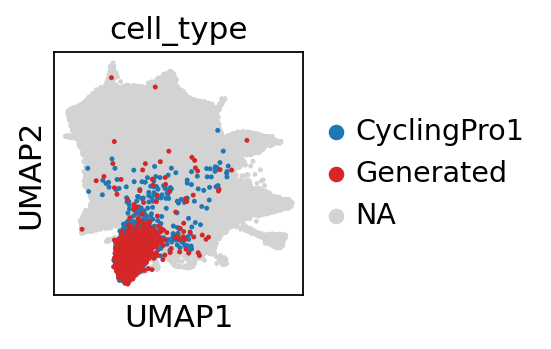

... storing 'dataset_type' as categorical


/tmp/ipykernel_2237525/4244391831.py:39: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


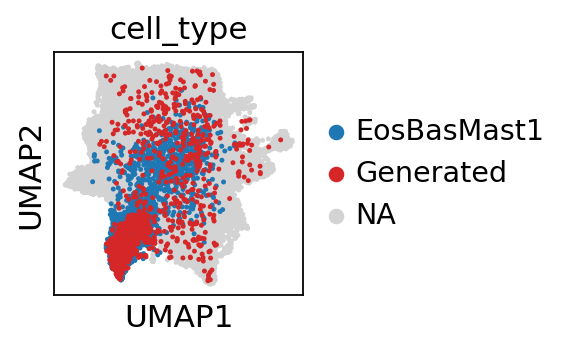

... storing 'dataset_type' as categorical


/tmp/ipykernel_2237525/4244391831.py:39: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


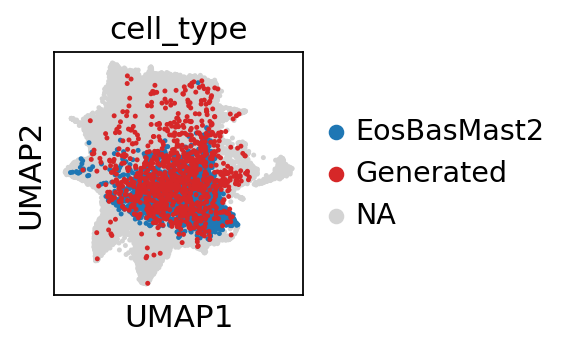

... storing 'dataset_type' as categorical


/tmp/ipykernel_2237525/4244391831.py:39: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


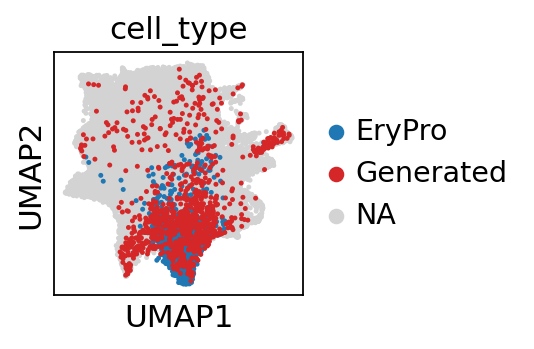

... storing 'dataset_type' as categorical


/tmp/ipykernel_2237525/4244391831.py:39: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


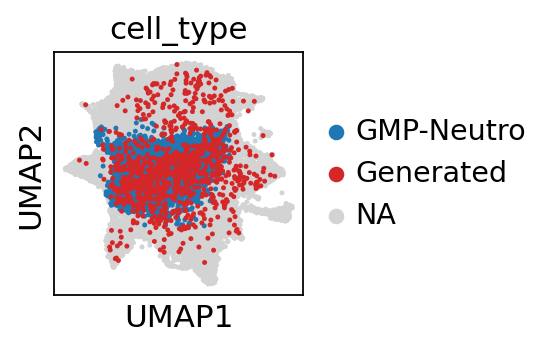

... storing 'dataset_type' as categorical


/tmp/ipykernel_2237525/4244391831.py:39: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


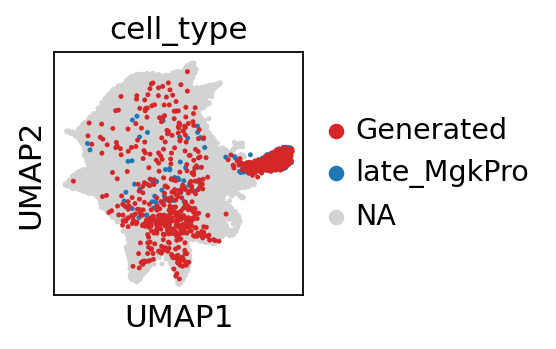

In [21]:
sc.set_figure_params(figsize=(2, 2))

TRUE_COLOR = "#1f77b4"
GENERATED_COLOR = "#d62728"

rng = np.random.default_rng(42)

for cell_type in concatenated_umaps:

    adata = concatenated_umaps[cell_type]
    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

    if cell_type == "MgkPro":
        cell_type_umap = "late_MgkPro"
    elif cell_type == "PreProB":
        cell_type_umap = "preProB"
    else:
        cell_type_umap = cell_type

    # fixed colors
    celltype_categories = list(adata.obs["cell_type"].cat.categories)

    celltype_color_map = {
        cat: GENERATED_COLOR if cat == "Generated" else "#d3d3d3"
        for cat in celltype_categories
    }

    celltype_color_map[cell_type_umap] = TRUE_COLOR

    adata.uns["cell_type_colors"] = [
        celltype_color_map[cat] for cat in celltype_categories
    ]

    # randomize plotting order
    shuffled_idx = rng.permutation(adata.n_obs)
    adata_shuffled = adata[shuffled_idx].copy()
    adata_shuffled = adata

    sc.pl.umap(
        adata_shuffled,
        color="cell_type",
        groups=[cell_type_umap, "Generated"],
        s=20,
        save=f"_{cell_type_umap}.png"
    )